CONVOLUTIONAL NEURAL NETWORK

In [1]:
import sys
!{sys.executable} -m pip install tensorflow
 


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
!{sys.executable} -m pip install matplotlib


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import tensorflow as tf #load image and make predictions
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,Dropout

In [5]:
test_dir=r"C:\Users\ELCOT\Documents\data  set\archive"

In [6]:
train=keras.utils.image_dataset_from_directory(
    test_dir,#makes path for each folder -- if cat 1st means -- cat--cat1.jpg,cat2.jpg --2nd dog 
    labels="inferred",#automatically assigns label names(cat) as which is folder name(cat)
    label_mode="int", #converts  all labels name into num format (cat-0),(dog-2)
    batch_size=8, #if images are more means ,we make it batch as 1st batch ,the count 32 ,so cnn work with 32 images
    image_size=(224,224)
)

Found 500 files belonging to 1 classes.


In [7]:
for images,labels in train.take(1): # 1is take 1st batch 32 images only
    print(images.shape)
    print(labels.shape)

(8, 224, 224, 3)
(8,)


In [8]:
def process(image,label):
    image=image/255  #makes all images from 0 to 1 so before that images sizes looks like 180,100,80,40
    return image,label
train=train.map(process) # applying this process to train dataset and the labels remains unchanged 
    

In [9]:
print(train)
print(images)
print(labels)

<_MapDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
tf.Tensor(
[[[[255. 255. 255.]
   [255. 255. 255.]
   [255. 255. 255.]
   ...
   [255. 255. 255.]
   [255. 255. 255.]
   [255. 255. 255.]]

  [[255. 255. 255.]
   [255. 255. 255.]
   [255. 255. 255.]
   ...
   [255. 255. 255.]
   [255. 255. 255.]
   [255. 255. 255.]]

  [[255. 255. 255.]
   [255. 255. 255.]
   [255. 255. 255.]
   ...
   [255. 255. 255.]
   [255. 255. 255.]
   [255. 255. 255.]]

  ...

  [[255. 255. 255.]
   [255. 255. 255.]
   [255. 255. 255.]
   ...
   [255. 255. 255.]
   [255. 255. 255.]
   [255. 255. 255.]]

  [[255. 255. 255.]
   [255. 255. 255.]
   [255. 255. 255.]
   ...
   [255. 255. 255.]
   [255. 255. 255.]
   [255. 255. 255.]]

  [[255. 255. 255.]
   [255. 255. 255.]
   [255. 255. 255.]
   ...
   [255. 255. 255.]
   [255. 255. 255.]
   [255. 255. 255.]]]


 [[[255. 255. 255.]
   [255. 255. 255.]
   [255. 255. 25

In [10]:
model=Sequential() # empty model 
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3))),#ReLU (Rectified Linear Unit),conv2D finds impt features ,so 32 filters find 32 diff features
model.add(MaxPooling2D((2,2))),# maxpooling reduces the image size, by choosing one high value in set of numbers
model.add(Conv2D(64,(3,3),activation='relu')), #here 64 makes more images so model learn with more images
model.add(MaxPooling2D((2,2))), #again here images size get reduced,and select high value
model.add(Conv2D(128,(3,3),activation='relu')), # 128 handle even more images
model.add(MaxPooling2D((2,2))),
model.add(Conv2D(1280,(3,3),activation='relu')),
model.add(MaxPooling2D((2,2))),
model.add(Flatten()),# makes the values in 2D to 1D(2 lines to 1line)
model.add(Dense(512,activation='relu'))#relu can handle more complexity so here 512 nuerons are there each nueron handle with every nueron.
model.add(Dense(4,activation='softmax'))#it makes probability with 4 classes with that it select one highest probability

c:\Users\ELCOT\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.compile(   # making the model training
    optimizer='adam',  # optimizer updates the mistakes and make the error less for more accurate
    loss="sparse_categorical_crossentropy", #measures how much the error
    metrics=['accuracy'] # tell how many predictions are correct
)

In [12]:
x=np.array(images)
y=np.array(labels)

In [13]:
import sys
!"{sys.executable}" -m pip install scikit-learn


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=50)

In [15]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(6, 224, 224, 3)
(6,)
(2, 224, 224, 3)
(2,)


In [16]:
history=model.fit(x_train,y_train,batch_size=8,epochs=30,validation_data=(x_test,y_test))#epochs means the model learns 50times

Epoch 1/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.0000e+00 - loss: 12.1086 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 1.0000 - loss: 0.0000e+

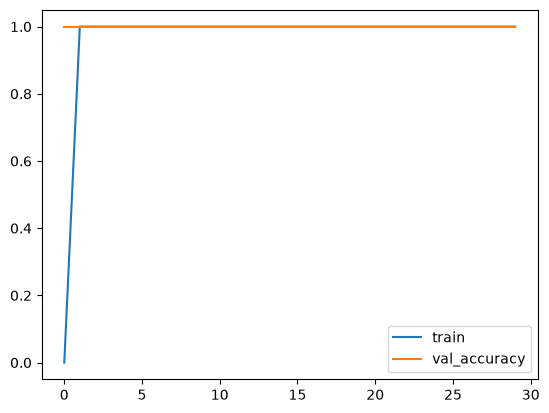

In [17]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],label='train')
plt.plot(history.history['val_accuracy'],label='val_accuracy') # val_accuracy means validation(testing)
plt.legend()
plt.show()

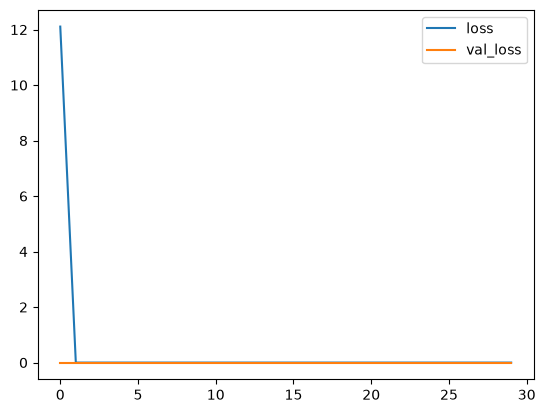

In [18]:
plt.plot(history.history['loss'],label='loss')
plt.plot(history.history['val_loss'],label='val_loss')
plt.legend()
plt.show()

In [ ]:
#import os

#for root, dirs, files in os.walk(r"C:\Users\ELCOT\Documents\data  set"):
    #for file in files:
        #if file.lower().endswith((".jpg", ".jpeg", ".png", ".ppm")):
            #print(os.path.join(root, file))

C:\Users\ELCOT\Documents\data  set\1089167491152695604.jpg
C:\Users\ELCOT\Documents\data  set\18129294.jpg
C:\Users\ELCOT\Documents\data  set\23833.jpg
C:\Users\ELCOT\Documents\data  set\5096160.jpg
C:\Users\ELCOT\Documents\data  set\5557528.jpg
C:\Users\ELCOT\Documents\data  set\723812971448196566.jpg
C:\Users\ELCOT\Documents\data  set\786300416229091926.jpg
C:\Users\ELCOT\Documents\data  set\gradient-digital-transformation-business-background.jpg
C:\Users\ELCOT\Documents\data  set\rm378-09.jpg
C:\Users\ELCOT\Documents\data  set\sl_122221_47450_06.jpg
C:\Users\ELCOT\Documents\data  set\archive\Grapevine_Leaves_Image_Dataset\Ak\Ak (1).png
C:\Users\ELCOT\Documents\data  set\archive\Grapevine_Leaves_Image_Dataset\Ak\Ak (10).png
C:\Users\ELCOT\Documents\data  set\archive\Grapevine_Leaves_Image_Dataset\Ak\Ak (100).png
C:\Users\ELCOT\Documents\data  set\archive\Grapevine_Leaves_Image_Dataset\Ak\Ak (11).png
C:\Users\ELCOT\Documents\data  set\archive\Grapevine_Leaves_Image_Dataset\Ak\Ak (12).

In [ ]:
#print(test_dir)

C:\Users\ELCOT\Documents\data  set\archive


In [ ]:
#import os

#for root, dirs, files in os.walk(r"C:\Users\ELCOT\Documents\data  set\archive"):
    #if len(files) > 0:
       # print("Folder:", root)
        ##print("First file:", files[0])
        #break

Folder: C:\Users\ELCOT\Documents\data  set\archive\Grapevine_Leaves_Image_Dataset
First file: Grapevine_Leaves_Image_Dataset_Citation_Request.txt


In [ ]:
#import os

#print(os.listdir(r"C:\Users\ELCOT\Documents\data  set\archive"))

['Grapevine_Leaves_Image_Dataset']


In [ ]:
#import os

#for root, dirs, files in os.walk(r"C:\Users\ELCOT\Documents\data  set\archive"):
    #for file in files:
       # if file.lower().endswith((".jpg", ".jpeg", ".png", ".ppm")):
            #print(os.path.join(root, file))
            #break
    #break

In [19]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image

class_names =  ['Ak', 'Ala_Idris', 'Buzgulu', 'Dimnit', 'Nazli']#we assigning class names in cat format which is in num format

img_path = r"C:\Users\ELCOT\Documents\data  set\archive\Grapevine_Leaves_Image_Dataset\Ak\Ak (1).png"#find the image 
img = image.load_img(img_path, target_size=(224,224))#load the image
img_array = image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Add batch dimension

predictions = model.predict(img_array)
score = predictions[0]

print("Predicted emotion:", class_names[np.argmax(score)])
print("Confidence: {:.2f}%".format(100 * np.max(score)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step
Predicted emotion: Ak
Confidence: 100.00%


Densenet121

In [20]:
base=tf.keras.applications.DenseNet121(   #Pre-trained Deep Learning Model
    include_top=False,  #not take the old answers which densenet already learn
    weights='imagenet',#takes the more examples from imagenet
    input_shape=(224,224,3),
    input_tensor=None,#shouldbe none because it automatically create output 
    pooling='avg',   #8 × 8 × 1024 -- 1024-- reduce parameters
    classes=4,
    classifier_activation="softmax",#makes the scores(8.1) into probabilities(85%)
)

In [21]:
model=Sequential([
    base,
    Flatten(),
    Dense(512,activation='relu'),
    Dropout(0.15),
    Dense(256,activation='relu'),
    Dropout(0.15),
    Dense(128,activation='relu'),
    Dropout(0.15),
    Dense(4,activation='softmax'),
])

In [22]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 1024)           │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,727,044 (29.48 MB)

 Trainable params: 7,643,396 (29.16 MB)

 Non-trainable params: 83,648 (326.75 KB)

In [23]:
from tensorflow.keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.0001),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [24]:
history=model.fit(x_train,y_train,batch_size=8,epochs=30,validation_data=(x_test,y_test))

Epoch 1/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 83s 83s/step - accuracy: 0.0000e+00 - loss: 1.9924 - val_accuracy: 0.0000e+00 - val_loss: 1.6865
Epoch 2/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.3333 - loss: 1.3582 - val_accuracy: 0.0000e+00 - val_loss: 1.3957
Epoch 3/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5000 - loss: 1.0967 - val_accuracy: 0.5000 - val_loss: 1.2561
Epoch 4/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.8614 - val_accuracy: 1.0000 - val_loss: 1.1396
Epoch 5/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.6667 - loss: 0.7895 - val_accuracy: 1.0000 - val_loss: 1.0095
Epoch 6/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.6025 - val_accuracy: 1.0000 - val_loss: 0.8865
Epoch 7/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.4909 - val_accuracy: 1.0000 - val_loss: 0.7809
Epoch 8/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.3940 - val_accuracy: 1.0000 - val_loss: 0.6778
Ep

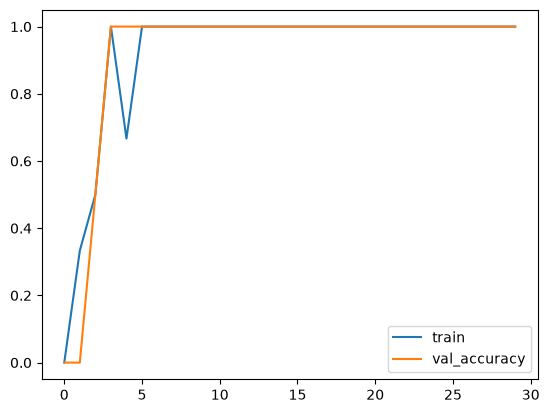

In [25]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],label='train')
plt.plot(history.history['val_accuracy'],label='val_accuracy')
plt.legend()
plt.show()

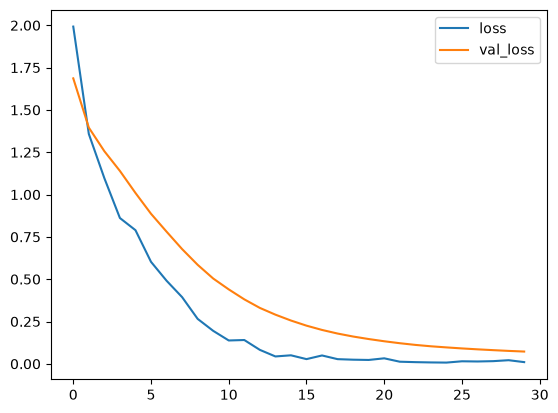

In [26]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'],label='loss')
plt.plot(history.history['val_loss'],label='val_loss')
plt.legend()
plt.show()

In [27]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
img_height = 224
img_width = 224
class_names =  ['Ak', 'Ala_Idris', 'Buzgulu', 'Dimnit', 'Nazli']#we assigning class names in cat format which is in num format

img_path = r"C:\Users\ELCOT\Documents\data  set\archive\Grapevine_Leaves_Image_Dataset\Ak\Ak (1).png"

#img_path = r"verymild.ppm"  # Change image path
img = image.load_img(img_path, target_size=(img_height, img_width))
img_array = image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Add batch dimension

predictions = model.predict(img_array)
score = predictions[0]


print("Predicted emotion:", class_names[np.argmax(score)])
print("Confidence: {:.2f}%".format(100 *np.max(score)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Predicted emotion: Ak
Confidence: 94.70%


VGG16

In [28]:
base1=tf.keras.applications.VGG16(
    include_top=False,
    weights='imagenet',
    input_tensor=None,
    input_shape=(224,224,3),
    pooling='avg',
    classes=4,
    classifier_activation='softmax'
)

In [29]:
model=Sequential([
    base1,
    Flatten(),
    Dense(512,activation='relu'),
    Dropout(0.15),
    Dense(256,activation='relu'),
    Dropout(0.15),
    Dense(6,activation='softmax')
])

In [30]:
from tensorflow.keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.0001),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [34]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop=EarlyStopping(monitor='val_loss',mode='min',verbose=1,patience=10)

In [36]:
history=model.fit(x_train,y_train,batch_size=8,epochs=10,validation_data=(x_test,y_test),callbacks=[early_stop])

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step - accuracy: 0.0000e+00 - loss: 7.6198 - val_accuracy: 0.0000e+00 - val_loss: 2.0261
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.0000e+00 - loss: 2.0467 - val_accuracy: 1.0000 - val_loss: 0.2666
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.6667 - loss: 0.7677 - val_accuracy: 1.0000 - val_loss: 7.1702e-04
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 1.0000 - val_loss: 3.5763e-06
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 1.0000 - loss: 3.3574e-05 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accura

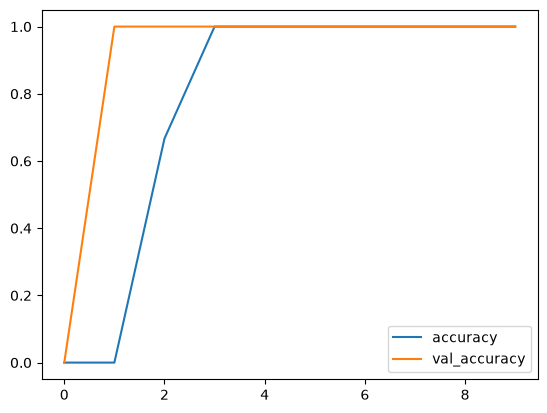

In [37]:
plt.plot(history.history['accuracy'],label='accuracy')
plt.plot(history.history['val_accuracy'],label='val_accuracy')
plt.legend()
plt.show()

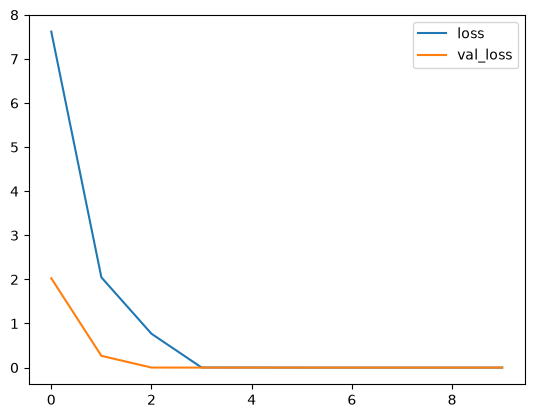

In [38]:
plt.plot(history.history['loss'],label='loss')
plt.plot(history.history['val_loss'],label='val_loss')
plt.legend()
plt.show()

In [39]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
img_height = 224
img_width = 224
class_names =  ['Ak', 'Ala_Idris', 'Buzgulu', 'Dimnit', 'Nazli']#we assigning class names in cat format which is in num format

img_path = r"C:\Users\ELCOT\Documents\data  set\archive\Grapevine_Leaves_Image_Dataset\Ak\Ak (1).png"

#img_path = r"verymild.ppm"  # Change image path
img = image.load_img(img_path, target_size=(img_height, img_width))
img_array = image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Add batch dimension

predictions = model.predict(img_array)
score = predictions[0]


print("Predicted emotion:", class_names[np.argmax(score)])
print("Confidence: {:.2f}%".format(100 *np.max(score)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted emotion: Ak
Confidence: 100.00%
